# 集成学习（Ensemble Learning）

集成学习通过组合多个"弱"或"强"学习器的预测结果来获得比单个模型更好的性能。主要分为两大类：
- **Bagging（并行集成）**：并行训练多个独立模型（如随机森林）
- **Boosting（串行集成）**：串行训练，后一个模型修正前一个模型的错误（如 AdaBoost、GBDT）

## 一、数据准备

In [ ]:
# 导入 NumPy 库，用于高效的数值计算和多维数组操作
import numpy as np
# 导入 matplotlib.pyplot 模块，用于绘制各种统计图表和数据可视化
import matplotlib.pyplot as plt
# 从 sklearn 中导入 datasets 模块，用于生成或加载标准机器学习数据集
from sklearn import datasets

### NumPy 布尔索引技巧演示

In [9]:
# np.arange(start, stop): 生成从 start 到 stop-1 的整数序列，返回一维 ndarray
# reshape(rows, cols): 将一维数组重塑为 3 行 4 列的二维矩阵（不复制数据，共享内存）
# 返回值: ndarray，shape=(3, 4)，dtype=int64
x = np.arange(0, 12).reshape(3, 4)

# 创建布尔类型的一维数组，用于后续的行索引操作
# np.array(object): 将 Python 列表转换为 ndarray
# 返回值: ndarray，dtype=bool，shape=(3,)
y = np.array([True, False, True])

# 打印布尔索引数组 y，查看其内容
print(y)
# 打印二维数组 x，查看其结构（3行4列）
print(x)

# 使用布尔索引进行高级索引操作
# x[y, 1]: y=[True, False, True] 选取第 0 行和第 2 行，再取这两行的第 1 列元素
# 返回值: ndarray，包含 x[0,1]=1 和 x[2,1]=9，即 array([1, 9])
x[y, 1]

[ True False  True]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


array([1, 9])

### 生成月牙形（Make Moons）数据集

In [2]:
# x 是特征矩阵，y 是对应的类别标签数组
# datasets.make_moons(): 生成两个交错的月牙形状数据集，适合测试非线性分类算法
# 参数说明:
#   n_samples (int): 生成的总样本数，这里生成 50000 个样本
#   noise (float): 添加到数据点的高斯噪声标准差，值越大数据越分散、越难分类
#   random_state (int): 随机种子，固定后每次运行生成的数据完全相同，保证可复现
# 返回值: tuple(ndarray, ndarray)
#   x: 特征矩阵，shape=(n_samples, 2)，每个样本有 2 个特征（x1坐标、x2坐标）
#   y: 标签数组，shape=(n_samples,)，值为 0 或 1，表示两个月牙类别
x, y = datasets.make_moons(n_samples=50000, noise=0.3, random_state=42)

# 打印特征矩阵的维度：(50000, 2)，表示 50000 个样本，每样本 2 个特征
print(x.shape)
# 打印标签数组的维度：(50000,)，表示 50000 个标签值
print(y.shape)
# np.unique(arr): 返回数组中去重后排序的元素，类型为 ndarray
# 打印标签的唯一值：[0, 1]，说明这是一个二分类问题
print(np.unique(y))

(50000, 2)
(50000,)
[0 1]


### 可视化月牙形数据集分布（散点图）

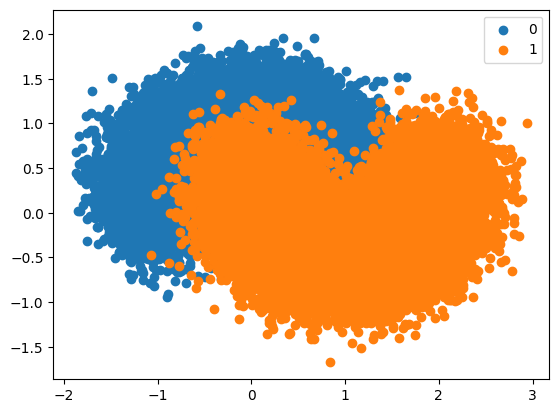

In [7]:
# 绘制散点图：展示标签为 0 的样本（月牙形下半部分）
# x[y == 0, 0]: 布尔索引，取标签为 0 的所有行的第 0 列（第一个特征）作为横坐标
# x[y == 0, 1]: 取标签为 0 的所有行的第 1 列（第二个特征）作为纵坐标
# plt.scatter(x轴数组, y轴数组): 绘制散点图，颜色由 matplotlib 自动分配
plt.scatter(x[y == 0, 0], x[y == 0, 1])

# 绘制散点图：展示标签为 1 的样本（月牙形上半部分）
# x[y == 1, 0]: 取标签为 1 的所有行的第 0 列作为横坐标
# x[y == 1, 1]: 取标签为 1 的所有行的第 1 列作为纵坐标
plt.scatter(x[y == 1, 0], x[y == 1, 1])

# 添加图例，字符串列表按照 scatter 的绘制顺序对应各系列
# plt.legend(labels): 参数 labels 为字符串列表
plt.legend(['0', '1'])

# 渲染并显示图形，两类样本会以不同颜色展示月牙形分布
plt.show()

In [ ]:
# x[y == 0, 0]

### 数据集预览与标签检查

In [5]:
# 查看数据集的前 10 个样本，验证特征矩阵的数据格式是否正确
# x[start:stop]: 切片操作，返回索引从 start 到 stop-1 的子数组
# 返回值: ndarray，shape=(10, 2)，每行为一个样本，包含两个浮点型特征值（x1, x2坐标）
x[0:10]

array([[ 0.71820567, -0.21809028],
       [ 0.11096372,  1.10964541],
       [ 0.61562814, -0.06539887],
       [ 0.46175947,  1.17926518],
       [ 1.22553968, -0.51211163],
       [ 1.27989488,  0.19395679],
       [ 0.51249388,  1.21727796],
       [ 1.97017831,  0.3277893 ],
       [ 0.63961463,  0.9269041 ],
       [ 0.38809941, -0.32770396]])

In [7]:
# 查看标签数组 y 中的唯一类别值
# np.unique(arr): 对数组去重并排序，返回唯一元素组成的 ndarray
# 返回值: ndarray，array([0, 1])，dtype=int64，确认是二分类问题（类别 0 和类别 1）
np.unique(y)

array([0, 1], dtype=int64)

### 划分训练集与测试集（Train-Test Split）

In [8]:
# 默认分割比例是 75%（训练集）和 25%（测试集）
# 导入 train_test_split 函数，用于随机划分数据集
from sklearn.model_selection import train_test_split

# train_test_split(X, y, random_state): 将特征矩阵和标签数组同步随机打乱并拆分
# 参数说明:
#   X (ndarray): 特征矩阵，shape=(50000, 2)
#   y (ndarray): 标签数组，shape=(50000,)
#   random_state (int): 随机种子，保证每次划分结果一致，便于复现实验
# 返回值（四个 ndarray）:
#   x_train: 训练集特征，shape=(37500, 2)，占总数据的 75%
#   x_test:  测试集特征，shape=(12500, 2)，占总数据的 25%
#   y_train: 训练集标签，shape=(37500,)
#   y_test:  测试集标签，shape=(12500,)
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

### 训练三个独立基分类器（单模型基准对比）

In [9]:
# 导入逻辑回归分类器
from sklearn.linear_model import LogisticRegression

# 逻辑回归是用于解决分类问题的线性模型（"强"分类器，效果好但有局限）
# LogisticRegression(): 使用默认参数创建逻辑回归实例
#   默认使用 L2 正则化，solver='lbfgs'，max_iter=100
# 返回值: LogisticRegression 对象
log_clf = LogisticRegression()  # 强分类器

# fit(X, y): 在训练集上拟合模型，学习特征与标签之间的关系
#   参数 X (ndarray): 训练集特征矩阵，shape=(37500, 2)
#   参数 y (ndarray): 训练集标签数组，shape=(37500,)
# 返回值: self（训练好的 LogisticRegression 对象）
log_clf.fit(x_train, y_train)

# score(X, y): 计算模型在给定数据上的分类准确率
#   参数 X (ndarray): 测试集特征矩阵，shape=(12500, 2)
#   参数 y (ndarray): 测试集真实标签，shape=(12500,)
# 返回值: float，准确率 = 预测正确的样本数 / 总样本数（约 0.853）
log_clf.score(x_test, y_test)

0.85344

In [10]:
# 导入支持向量机分类器（Support Vector Classifier）
from sklearn.svm import SVC

# SVC(): 创建支持向量机分类器实例（强分类器）
# SVM 通过寻找能最大化间隔的超平面来分离不同类别的数据
# 默认使用 RBF 核函数，适合非线性分类问题（如月牙形数据）
# 返回值: SVC 对象
svm_clf = SVC()  # 支持向量机，强分类器

# fit(X, y): 在训练集上训练 SVM 模型，寻找最优分类超平面
#   参数 X (ndarray): 训练集特征矩阵，shape=(37500, 2)
#   参数 y (ndarray): 训练集标签数组，shape=(37500,)
# 返回值: self（训练好的 SVC 对象）
svm_clf.fit(x_train, y_train)

# score(X, y): 计算 SVM 在测试集上的分类准确率
# 返回值: float，准确率（约 0.912，高于逻辑回归，因 RBF 核能捕获非线性边界）
svm_clf.score(x_test, y_test)

0.91216

In [11]:
# 导入决策树分类器
from sklearn.tree import DecisionTreeClassifier

# DecisionTreeClassifier(): 使用默认参数创建决策树分类器（强分类器）
# 默认不限制深度（max_depth=None），可能完全拟合训练数据（存在过拟合风险）
# 返回值: DecisionTreeClassifier 对象
dt_clf = DecisionTreeClassifier()

# fit(X, y): 在训练集上递归地划分特征空间，构建决策树
#   参数 X (ndarray): 训练集特征矩阵，shape=(37500, 2)
#   参数 y (ndarray): 训练集标签数组，shape=(37500,)
# 返回值: self（训练好的决策树对象）
dt_clf.fit(x_train, y_train)

# score(X, y): 计算决策树在测试集上的分类准确率
# 返回值: float，准确率（约 0.876，因过拟合泛化能力弱于 SVM）
dt_clf.score(x_test, y_test)

0.87624

# 1 手动实现投票分类器

In [12]:
# 使用三个已训练好的模型分别对测试集进行预测，为后续投票做准备
# predict(X): 对输入数据进行类别预测
#   参数 X (ndarray): 测试集特征矩阵，shape=(12500, 2)
#   返回值: ndarray，预测的类别标签，值为 0 或 1，shape=(12500,)

# 逻辑回归模型的预测结果
y_predict1 = log_clf.predict(x_test)
# 支持向量机模型的预测结果
y_predict2 = svm_clf.predict(x_test)
# 决策树模型的预测结果
y_predict3 = dt_clf.predict(x_test)

In [13]:
# 手动实现硬投票（Hard Voting）：三个分类器"少数服从多数"
# 核心思想：将三个模型的预测结果相加
#   由于标签只有 0 和 1，三者之和的范围为 [0, 3]
#   当至少 2 个分类器预测为 1 时（总和 >= 2），最终判定为类别 1，否则为类别 0
# y_predict1 + y_predict2 + y_predict3: 逐元素相加，返回 ndarray，每个元素为投票总数
# >= 2: 逐元素比较，返回布尔数组（True 表示多数投票为 1）
# dtype='int': 将布尔值转换为整数（True->1, False->0）
# 返回值: ndarray，最终集成预测标签，shape=(12500,)，dtype=int
y_predict = np.array((y_predict1 + y_predict2 + y_predict3) >= 2, dtype='int')

# 查看前 10 个集成预测结果，用于与真实标签对比验证
y_predict[:10]

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 1])

In [10]:
# 查看测试集的前 10 个真实标签，与 y_predict[:10] 对比判断预测是否正确
# y_test[:10]: 切片操作，返回测试集标签的前 10 个元素
# 返回值: ndarray，shape=(10,)，dtype=int64
y_test[:10]

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 1], dtype=int64)

In [14]:
# 导入 accuracy_score，用于计算分类准确率
from sklearn.metrics import accuracy_score

# accuracy_score(): 计算分类模型的预测准确率
# 参数说明:
#   y_true (ndarray): 真实标签数组，shape=(12500,)
#   y_pred (ndarray): 模型预测标签数组，shape=(12500,)
# 返回值: float，准确率 = 预测正确的样本数 / 总样本数（约 0.905）
# 对比单个分类器：逻辑回归 0.853、SVM 0.912、决策树 0.876
# 集成后（0.905）优于逻辑回归和决策树，体现了集成学习的优势
accuracy_score(y_test, y_predict)

0.90464

# 2 集成学习VotingClassifier(并行)

In [15]:
# 导入 sklearn 提供的集成投票分类器
from sklearn.ensemble import VotingClassifier

# VotingClassifier: 通过聚合多个分类器的预测结果来提升整体性能
# 参数说明:
#   estimators (list of (str, estimator)): 基分类器列表，每个元素是 (名称, 分类器实例) 的元组
#     名称 (str): 分类器的标识符，用于后续访问子分类器
#     分类器实例: 任意实现了 fit/predict 接口的 sklearn 分类器
#   voting (str): 投票策略
#     'hard': 硬投票，每个分类器投出一票（预测类别），取得票最多的类别作为最终结果
#     'soft': 软投票，取各分类器输出概率的均值，选概率最高的类别（需要分类器支持 predict_proba）
# hard 模式就是少数服从多数（3个分类器中至少2个同意才选该类别）
voting_clf = VotingClassifier(estimators=[
    ('log_clf', LogisticRegression()),      # 基分类器 1：逻辑回归
    ('svm_clf', SVC()),                      # 基分类器 2：支持向量机
    ('dt_clf', DecisionTreeClassifier())],   # 基分类器 3：决策树
    voting='hard')                           # 使用硬投票策略

In [16]:
# fit(X, y): 依次训练所有基分类器（逻辑回归、SVM、决策树）
#   参数 X (ndarray): 训练集特征矩阵，shape=(37500, 2)
#   参数 y (ndarray): 训练集标签数组，shape=(37500,)
# 返回值: self（训练好的 VotingClassifier 对象）
voting_clf.fit(x_train, y_train)

# score(X, y): 计算硬投票集成分类器在测试集上的准确率
# 返回值: float，准确率（约 0.904）
print(voting_clf.score(x_test, y_test))

# predict(X): 对测试集进行集成预测，通过硬投票确定每个样本的类别
# 返回值: ndarray，shape=(12500,)，dtype=int64
# [:10]: 查看前 10 个预测结果
voting_clf.predict(x_test)[:10]

0.90448


array([1, 1, 1, 0, 0, 0, 0, 0, 0, 1], dtype=int64)

更合理的投票，应该有权值
唱歌比赛的投票?(评委的投票权重与观众不一样)

In [17]:
# hard 与 soft 投票的核心区别：
#   hard 投票：每个分类器投一票（类别标签），取得票最多的类别
#   soft 投票：每个分类器输出各类别的概率，取概率均值最大的类别（更充分利用置信度信息）
# 注意：soft 投票训练时间较长，因为 SVC 需要启用概率估计（内部使用交叉验证）
voting_clf2 = VotingClassifier(estimators=[
    ('log_clf', LogisticRegression()),
    # SVC 默认不支持概率输出，必须设置 probability=True 才能参与 soft 投票
    # probability=True: 使用 Platt 缩放拟合概率，会增加训练时间
    ('svm_clf', SVC(probability=True)),
    ('dt_clf', DecisionTreeClassifier())],
    voting='soft')   # 使用软投票策略

# fit(X, y): 训练所有基分类器，并为 SVC 拟合概率模型
voting_clf2.fit(x_train, y_train)

# score(X, y): 计算软投票集成分类器在测试集上的准确率
# 返回值: float（约 0.904），与硬投票效果相近，部分情况下 soft 更优
voting_clf2.score(x_test, y_test)

0.90384

# 使用bagging,并行

In [16]:
# 计算训练集的样本数量（总样本 × 训练集比例）
# train_test_split 默认按 75% 划分训练集，因此训练集共有 37500 个样本
# 这个值是 BaggingClassifier 中 max_samples 参数的上限（有放回抽样不能超过训练集大小）
50000 * 0.75

37500.0

In [18]:
# 导入决策树分类器，作为 Bagging 的基分类器（弱学习器）
from sklearn.tree import DecisionTreeClassifier
# 导入 Bagging 集成分类器
from sklearn.ensemble import BaggingClassifier

# BaggingClassifier: Bootstrap Aggregating，通过对训练集进行有放回抽样构建多个模型并投票
# 参数说明:
#   base_estimator (estimator): 基分类器，这里使用决策树
#   n_estimators (int): 基分类器（决策树）的数量，数目越多模型越稳健，但训练越慢
#   max_samples (int/float): 每棵树训练时从训练集中抽取的样本数（不能超过训练集大小 37500）
#   bootstrap (bool): True 表示有放回抽样（Bootstrap），False 表示无放回抽样
# 返回值: BaggingClassifier 对象
bagging_clf = BaggingClassifier(DecisionTreeClassifier(),
                                n_estimators=300,    # 集成 300 棵决策树
                                max_samples=3000,    # 每棵树抽取 3000 个样本（有放回）
                                bootstrap=True)      # 使用有放回的 Bootstrap 采样

# fit(X, y): 并行/串行训练 300 棵决策树，每棵树使用独立的 Bootstrap 样本
bagging_clf.fit(x_train, y_train)

# score(X, y): 计算 Bagging 集成分类器在测试集上的准确率
# 返回值: float（约 0.912），多棵树的集成效果优于单棵决策树
bagging_clf.score(x_test, y_test)

0.91232

# 3 oob设计

In [19]:
# 导入决策树分类器作为基分类器
from sklearn.tree import DecisionTreeClassifier
# 导入 Bagging 集成分类器
from sklearn.ensemble import BaggingClassifier

# 袋外评估（Out-Of-Bag, OOB）原理：
#   使用有放回抽样（Bootstrap）时，每次约有 63.2% 的样本被选中
#   剩余约 36.8% 未被选中的样本称为"袋外样本"，它们可以作为天然的验证集
#   因此无需额外拆分验证集，节省数据

# 新增参数说明:
#   oob_score (bool): True 表示启用袋外样本评估，训练后自动计算 oob_score_
# 返回值: BaggingClassifier 对象
bagging_clf2 = BaggingClassifier(DecisionTreeClassifier(),
                                 n_estimators=500,     # 集成 500 棵决策树
                                 max_samples=1000,     # 每棵树抽取 1000 个样本（有放回）
                                 bootstrap=True,       # 有放回抽样（OOB 评估的前提）
                                 oob_score=True)       # 启用袋外样本评估

# fit(X, y): 训练模型，同时记录每个样本作为袋外样本的次数
bagging_clf2.fit(x_train, y_train)

# oob_score_: 属性，使用袋外样本计算的准确率（float）
# 等价于免费的交叉验证，无需额外准备验证集（约 0.916）
bagging_clf2.oob_score_

0.91592

In [20]:
# 使用测试集评估 Bagging 分类器的准确率，与 oob_score_ 对比验证一致性
# score(X, y): 计算在给定数据上的平均准确率
#   参数 X (ndarray): 测试集特征矩阵，shape=(12500, 2)
#   参数 y (ndarray): 测试集真实标签，shape=(12500,)
# 返回值: float（约 0.913），与 oob_score_（约 0.916）接近，说明 OOB 评估可靠
bagging_clf2.score(x_test, y_test)

0.91256

### njobs

In [19]:
# 导入决策树分类器，用于集成上千棵模型
from sklearn.tree import DecisionTreeClassifier
# 导入 Bagging 集成分类器
from sklearn.ensemble import BaggingClassifier

In [21]:
%%time
# %%time: Jupyter 魔法命令，统计该 Cell 的执行时间，输出包含：
#   CPU times: 实际 CPU 计算消耗的时间（不含 I/O 等待）
#   Wall time: 墙上时钟时间（真实流逝时间，包含进程启动、I/O等待等所有开销）
# 此处不使用并行（n_jobs 默认为 1），用于与多核版本对比性能

# 创建不使用并行的 Bagging 分类器
bagging_clf = BaggingClassifier(DecisionTreeClassifier(),
                                n_estimators=500,   # 训练 500 棵决策树
                                max_samples=2000,   # 每棵树抽取 2000 个样本
                                bootstrap=True)     # 有放回抽样

# fit(): 串行训练 500 棵决策树（单核，CPU time ≈ Wall time）
bagging_clf.fit(x_train, y_train)
# score(): 计算测试集准确率
bagging_clf.score(x_test, y_test)

CPU times: total: 2.31 s
Wall time: 2.36 s


0.91232

In [22]:
%%time
# %%time 必须顶格写在 Cell 第一行，才能正确统计整个 Cell 的执行时间
# 多核并行训练：Wall time 明显小于单核版本，CPU time 反而更高（多核调度开销）

# 创建使用多核并行的 Bagging 分类器
bagging_clf = BaggingClassifier(DecisionTreeClassifier(),
                                n_estimators=500,   # 训练 500 棵决策树
                                max_samples=2000,   # 每棵树抽取 2000 个样本
                                bootstrap=True,     # 有放回抽样
                                # n_jobs (int): 并行运行的作业数
                                #   -1: 使用所有可用的 CPU 核心（推荐）
                                #   正整数 n: 使用 n 个核心
                                n_jobs=-1)

# fit(): 并行训练 500 棵决策树，各核心独立运行，Wall time 显著降低
bagging_clf.fit(x_train, y_train)
# score(): 计算测试集准确率（与单核版本准确率相同，但训练更快）
bagging_clf.score(x_test, y_test)

CPU times: total: 234 ms
Wall time: 2.34 s


0.9116

# 4 bootstrap_features  对特征进行采样

In [23]:
# 随机子空间法（Random Subspaces）：只对特征进行随机采样，而不对样本采样
# 由于我们只有 2 个特征，设置 max_features=1 相当于每棵树只能使用 1 个特征
# 特征太少会导致准确率偏低（不适合特征数少的场景）

# 新增参数说明:
#   max_features (int/float): 每个基分类器使用的最大特征数量
#     int: 直接指定特征数，这里设为 1（从 2 个特征中只选 1 个）
#     float: 按比例取特征数（如 0.5 则取 50% 的特征）
#   bootstrap_features (bool): True 表示对特征进行有放回抽样（允许特征重复选取）
# 返回值: BaggingClassifier 对象
random_subspaces_clf = BaggingClassifier(DecisionTreeClassifier(),
                                         n_estimators=500,           # 集成 500 棵树
                                         max_samples=500,             # 每棵树抽取 500 个样本
                                         oob_score=True,              # 启用袋外评估
                                         bootstrap=True,              # 样本有放回抽样
                                         n_jobs=-1,                   # 使用全部 CPU 核心
                                         max_features=1,              # 每棵树只使用 1 个特征
                                         bootstrap_features=True)     # 特征有放回抽样

# fit(X, y): 在全量数据集上训练（同时含训练集和测试集，通过 OOB 评估代替测试集）
random_subspaces_clf.fit(x, y)

# oob_score_: 袋外样本评估准确率（float）
# 因为特征太少，准确率偏低（约 0.881），说明随机子空间在特征少时效果不佳
random_subspaces_clf.oob_score_

0.88122

In [25]:
# 故意设置错误参数，验证 max_samples 不能超过数据集的总样本数
# 随机补丁法（Random Patches）：同时对样本和特征都进行随机采样
# 注意：当 bootstrap=True 时，max_samples 不能超过数据集大小（这里数据集有 50000 个样本）
# 设置 max_samples=50001 会触发 ValueError 异常
random_patches_clf = BaggingClassifier(DecisionTreeClassifier(),
                                       n_estimators=500,
                                       max_samples=50001,            # 故意超出数据集大小 50000，触发报错
                                       oob_score=True,
                                       bootstrap=True,
                                       n_jobs=-1,
                                       max_features=1,
                                       bootstrap_features=True)

# 调用 fit() 时会抛出 ValueError，因为 max_samples 超出了数据集总样本数 50000
random_patches_clf.fit(x, y)
random_patches_clf.oob_score_
# 注：同时对样本和特征进行随机采样的算法就是随机森林（Random Forest）的核心思想

ValueError: max_samples must be <= n_samples

## 随机森林（Random Forest）

In [26]:
# 导入随机森林分类器
# RandomForestClassifier 是对"随机补丁法（Random Patches）"的专门优化实现
# 相比手动用 BaggingClassifier 实现，随机森林有更多的参数调节和内部优化
from sklearn.ensemble import RandomForestClassifier

In [27]:
%%time
# 在全量数据集上训练随机森林，使用 OOB 评估（无需单独的测试集）
# RandomForestClassifier 参数说明:
#   n_estimators (int): 森林中决策树的棵数，越多结果越稳定但训练越慢
#   random_state (int): 随机种子，确保每次运行结果一致，便于复现
#   oob_score (bool): True 表示使用袋外样本计算评估分数（需要 bootstrap=True，默认开启）
#   n_jobs (int): -1 表示使用全部 CPU 核心并行构建各棵树
# 返回值: RandomForestClassifier 对象
rc_clf = RandomForestClassifier(n_estimators=500,    # 构建 500 棵决策树
                                random_state=666,    # 固定随机种子
                                oob_score=True,      # 启用袋外评估
                                n_jobs=-1)           # 全核并行

# fit(X, y): 在全量数据集（50000 个样本）上训练随机森林
rc_clf.fit(x, y)

# oob_score_: 袋外样本评估准确率（float），约 0.903
rc_clf.oob_score_

CPU times: total: 32.8 s
Wall time: 2.73 s


0.90268

In [28]:
%%time
# 使用训练集训练随机森林，在测试集上评估（标准评估流程）
# 参数说明（新增）:
#   max_samples (int/float): 每棵树训练时抽取的样本数量
#     这里设为 37500，即训练集的全部样本（有放回抽样，每棵树实际看到的样本有重复）
# 返回值: RandomForestClassifier 对象
rc_clf = RandomForestClassifier(max_samples=37500,   # 每棵树从训练集（37500样本）中有放回抽样
                                n_jobs=-1)           # 使用全部 CPU 核心并行训练

# fit(X, y): 在训练集上训练随机森林
rc_clf.fit(x_train, y_train)

# score(X, y): 计算在测试集上的准确率
# 返回值: float（约 0.904）
rc_clf.score(x_test, y_test)

CPU times: total: 4.5 s
Wall time: 304 ms


0.90448

In [29]:
%%time
# 通过限制最大叶子节点数来控制每棵树的复杂度，防止过拟合
# 新增参数说明:
#   max_leaf_nodes (int): 每棵决策树允许的最大叶子节点数
#     限制叶子节点数量 = 限制树的复杂度 = 减少过拟合的风险
#     设置为 16 意味着每棵树最多分出 16 个叶子节点（相对较浅）
#     通常取 2 的幂次（如 16、32、64），便于与树深度对应理解
# 返回值: RandomForestClassifier 对象
rc_clf2 = RandomForestClassifier(n_estimators=500,       # 构建 500 棵树
                                  max_leaf_nodes=16,     # 每棵树最多 16 个叶子节点（约等于深度 4）
                                  random_state=666,      # 固定随机种子
                                  oob_score=True,        # 启用袋外评估
                                  n_jobs=-1)             # 全核并行

# fit(X, y): 在全量数据集上训练随机森林
rc_clf2.fit(x, y)

# oob_score_: 袋外样本评估准确率（float，约 0.910），限制叶子节点后效果略有提升
rc_clf2.oob_score_

CPU times: total: 13.7 s
Wall time: 1.61 s


0.90962

# 5 Extra-Trees
ExtraTreesClassifier 是一种机器学习算法，属于基于决策树的集成方法家族。
它随机选择特征子集和数据样本来构建多个决策树，并将它们的预测聚合起来做出最终预测。
它可用于分类任务，并以处理嘈杂和高维数据的能力而闻名。

In [30]:
# 导入极端随机树分类器（Extremely Randomized Trees）
from sklearn.ensemble import ExtraTreesClassifier

# ExtraTreesClassifier（极端随机树）与随机森林的对比：
#   随机森林：随机选取特征子集，在子集上寻找最优分割点（贪心搜索）
#   极端随机树：随机选取特征子集，分割点也是随机生成的（更加随机化）
#     优点：训练速度更快（无需寻找最优分割点），有时泛化能力更强
#     缺点：单棵树偏差略高（但通过集成大量树抵消）
# 参数说明:
#   n_estimators (int): 树的数量，500 棵
#   oob_score (bool): True 启用袋外评估（需配合 bootstrap=True 使用）
#   bootstrap (bool): True 表示有放回抽样（极端随机树默认不使用 bootstrap，这里手动开启）
#   n_jobs (int): -1 使用全部 CPU 核心并行训练
# 返回值: ExtraTreesClassifier 对象
et_clf = ExtraTreesClassifier(n_estimators=500,    # 构建 500 棵极端随机树
                               oob_score=True,     # 启用袋外评估
                               bootstrap=True,     # 启用有放回抽样（才能使用 OOB）
                               n_jobs=-1)          # 使用全部 CPU 核心

# fit(X, y): 在全量数据集上训练极端随机树
et_clf.fit(x, y)

# oob_score_: 袋外样本评估准确率（float，约 0.907）
et_clf.oob_score_

0.90708

# Boosting

# 5 串行（包含adaboost和GBDT）

In [32]:
# 导入 AdaBoost 集成分类器（Adaptive Boosting，自适应提升算法）
# AdaBoost 是一种串行集成方法：每个新的基分类器专注修正前一个分类器的错误
# 核心思想：增大被错误分类样本的权重，减小正确分类样本的权重，迭代改进
from sklearn.ensemble import AdaBoostClassifier

# 导入决策树分类器，作为 AdaBoost 的弱基分类器（也可使用默认的决策树桩 max_depth=1）
from sklearn.tree import DecisionTreeClassifier

In [33]:
%%time
# AdaBoostClassifier 参数说明:
#   base_estimator (estimator): 弱基分类器，这里使用默认参数的决策树
#     AdaBoost 通常配合浅树（如决策树桩 max_depth=1）效果最佳
#   n_estimators (int): 串行训练的基分类器数量
#     注意：AdaBoost 是串行训练（每棵树依赖上一棵），无法并行，CPU time ≈ Wall time
# 返回值: AdaBoostClassifier 对象
ada_clf = AdaBoostClassifier(DecisionTreeClassifier(),   # 以完整决策树为弱分类器
                              n_estimators=500)           # 串行训练 500 棵树

# fit(X, y): 串行训练 500 棵决策树，每棵树都根据前一棵树的错误调整样本权重
#   参数 X (ndarray): 训练集特征矩阵，shape=(37500, 2)
#   参数 y (ndarray): 训练集标签数组，shape=(37500,)
ada_clf.fit(x_train, y_train)

# score(X, y): 计算 AdaBoost 在测试集上的准确率
# 返回值: float（约 0.875），效果一般，因为使用了完整决策树（过拟合）
ada_clf.score(x_test, y_test)

CPU times: total: 93.8 ms
Wall time: 93.1 ms


0.87504

### 梯度提升分类器（Gradient Boosting Decision Tree, GBDT）

In [34]:
# 导入梯度提升分类器（Gradient Boosting Decision Tree, GBDT）
# GBDT 默认使用决策树作为基分类器，增加树的数量后准确率通常会提升
from sklearn.ensemble import GradientBoostingClassifier

# GradientBoostingClassifier 核心思想：
#   每棵新树拟合前一棵树的"残差"（预测误差的梯度方向），逐步修正错误
#   与 AdaBoost 的区别：AdaBoost 调整样本权重；GBDT 直接拟合残差（梯度）
# 参数说明:
#   max_depth (int): 每棵决策树的最大深度
#     GBDT 通常使用较浅的树（3~5 层），避免单棵树过拟合（与随机森林不同）
#   n_estimators (int): 串行训练的决策树数量，越多效果越好（但可能过拟合）
# 返回值: GradientBoostingClassifier 对象
gb_clf = GradientBoostingClassifier(max_depth=3,        # 每棵树最大深度为 3（防止单树过拟合）
                                     n_estimators=500)  # 串行训练 500 棵树

# fit(X, y): 串行训练梯度提升树，每棵树拟合前一棵树的残差
#   参数 X (ndarray): 训练集特征矩阵，shape=(37500, 2)
#   参数 y (ndarray): 训练集标签数组，shape=(37500,)
gb_clf.fit(x_train, y_train)

# score(X, y): 计算 GBDT 在测试集上的准确率
# 返回值: float（约 0.912），效果明显好于 AdaBoost
gb_clf.score(x_test, y_test)

0.9124

### AdaBoost 权重公式推导验证

In [3]:
# 导入 NumPy 用于数学运算
import numpy as np

# 验证 AdaBoost 中基分类器权重的计算公式
# 权重公式：α = ln((1 - 错误率) / 错误率) = ln(1/错误率 - 1)
# 规律：错误率越低（分类器越好），权重 α 越大；错误率=0.5时权重为0（随机猜测）

# 当错误率 = 0.1 时：α = ln((1-0.1)/0.1) = ln(9) ≈ 2.20
# np.log(x): 计算自然对数（以 e ≈ 2.718 为底），返回 float
# 结果约 2.197，说明错误率低的分类器在最终投票中权重更大
print(np.log(9))

# 当错误率 = 0.5 时：α = ln((1-0.5)/0.5) = ln(1) = 0
# 错误率为 0.5 等同于随机猜测，该分类器对集成毫无贡献，权重为 0
# 返回值: float，值为 0.0
np.log((1 - 0.5) / 0.5)

2.1972245773362196


0.0

In [35]:
!ls

01.py
02.py
03.py
03_鏁版嵁淇濆瓨.py
04.py
1-鐗瑰緛宸ョ▼.ipynb
1-鐗瑰緛宸ョ▼_鍐茬獊鏂囦欢_41507_20250109210024.ipynb
2-鏈哄櫒瀛︿範鍒嗙被绠楁硶.ipynb
3-鏈哄櫒瀛︿範鍥炲綊绠楁硶.ipynb
4-鑱氱被.ipynb
5-闆嗘垚瀛︿範.ipynb
6.绉掓暟杞�涓烘寚瀹氭牸寮忔棩鏈�-璁哄潧.py
6.绉掓暟杞�涓烘寚瀹氭牸寮忔棩鏈�-璁哄潧_鍐茬獊鏂囦欢_41507_20240401190426.py
data
ovr涓巓vo闂�棰�.py
svm.ipynb
test1.ipynb
test1.py
test2.ipynb
test2.py
test-鐪媡f婧愮爜.py
tmp
tmp.7z
train_set.csv
tree.dot
tree.png
tree1.dot
tree1.png
